In [34]:
import matplotlib.pyplot as plt
import pandas as pd
import collections
import os

Matplotlib is building the font cache; this may take a moment.


In [2]:
def getAlignments(refFile):
    '''
    Loosely based off Josh's compareAlignmentsAcrossReadFiles.py script.
    '''
    aa=collections.defaultdict(list)
    with open(refFile,'r') as f:
        ids = []
        for line in f:
            if not line.startswith('@'):
                try:
                    line=line.rstrip().split('\t')
                    readID=line[0]
                    ids.append(readID)
                    strand=int(line[1])
                    chrName=line[2]
                    hitLoc=int(line[3])
                    score='na'
                    ##
                    for entry in line:
                        if entry.startswith('AS:i:'):
                            score=int(entry.split(':')[-1])
                    ##
                    if strand==0 and score!='na':
                        if readID in aa:
                            if score>aa[readID][-1]:
                                aa[readID].append((chrName,hitLoc,score))
                        else:
                            aa[readID].append((chrName,hitLoc,score))
                except ValueError:
                    pass
    ##
    bb={}
    print(len(ids))
    for k,v in aa.items():
        if len(v)==1:
            bb[k]=v[0]
    ##
    return bb

In [3]:
refAlignments = getAlignments('/data16/liam/mutated_files/aligned/ref_mapping.sam')
refAlignments

1416504


{'d758e1be-96de-46dc-815e-e9c3c60823ff': ('V', 13411322, 150),
 'fcefa0f1-bd07-4574-b7be-cc71f0cee5d2': ('IV', 4388345, 321),
 '0d687fae-50a6-4be3-a35b-a547a7afc6d0': ('II', 5055610, 267),
 'ef9f176d-7795-422a-9d1f-0f3fcc94b071': ('V', 9398382, 1005),
 'd684af85-1cb5-4f47-a0c6-8828a549f7c1': ('MtDNA', 5700, 543),
 '96c494df-1e21-49d4-a791-f4cdf4f00aa1': ('II', 1151626, 559),
 '2c4b6f69-89aa-4dfe-90f7-17f3f7e6ac2f': ('X', 14687035, 233),
 'b0fe7897-da68-4b08-a4d9-d35447afd84e': ('MtDNA', 5053, 369),
 '12a188f6-43c6-4634-a654-4716cd07f246': ('X', 3260792, 372),
 'da7c0e93-7dc5-4a7e-8cef-011ae93004cb': ('V', 12995780, 295),
 'd2c0afac-b993-4f3c-8d3f-0eb2a4dd9538': ('X', 6791193, 707),
 '0106420e-de4b-4670-8bf5-295f009de6ce': ('II', 9288726, 181),
 '880da4cc-61c0-4578-9692-ea3408b90c47': ('V', 12637657, 227),
 'c0deae94-bbc8-423a-af1e-7593a5058bce': ('I', 10568569, 347),
 'd0901719-2188-4068-ab92-50fe05c7276d': ('III', 2786397, 88),
 'a00245dc-8d3a-4aa3-bf40-7e6178557257': ('V', 12191769, 

In [7]:
import os
mutated_files = [filename for filename in os.listdir('/data16/liam/mutated_files/aligned/') if filename.startswith("mod_mapping")]
#os.chdir('/data16/liam/mutated_files/aligned/')
#mutatedAlignments=[getAlignments(m) for m in mutated_files]

In [8]:
d = {}
refAlignments = getAlignments('/data16/liam/mutated_files/aligned/ref_mapping.sam')
os.chdir('/data16/liam/mutated_files/aligned/')
for file in mutated_files:
    d[file] = getAlignments(file)
     

1416504
1237697
1101473
701551
941021
749827
651872
535015
496174
600519
499934
551336
930392
769118
623167
841046
791673
515340


In [38]:
alignmentDict = {}
for i in mutated_files:
    alignmentDict[i] = None
for mut in d:
    aligned = []
    similar = []
    notSimilar = []
    for readID in refAlignments:
        alignment = refAlignments[readID]
        if readID in d[mut]:
            aligned.append(readID)
            #was it aligned to a similar place
            if d[mut][readID][0] == alignment[0]:
                if abs(d[mut][readID][1]-alignment[1])<=1000:
                        similar.append(readID)
                else:
                    notSimilar.append(readID)
    alignmentDict[mut] = [len(aligned), len(similar)]

In [19]:
alignmentDict

{'mod_mapping0.20.sam': [629882, 618649],
 'mod_mapping0.25.sam': [587253, 574982],
 'mod_mapping0.80.sam': [640431, 611731],
 'mod_mapping1.00.sam': [706009, 668176],
 'mod_mapping0.85.sam': [673155, 639932],
 'mod_mapping0.75.sam': [601080, 574110],
 'mod_mapping0.45.sam': [456667, 440155],
 'mod_mapping0.55.sam': [459022, 440404],
 'mod_mapping0.70.sam': [556942, 534936],
 'mod_mapping0.50.sam': [451527, 435120],
 'mod_mapping0.65.sam': [514252, 493337],
 'mod_mapping0.30.sam': [542593, 527997],
 'mod_mapping0.35.sam': [509196, 493966],
 'mod_mapping0.40.sam': [476051, 459953],
 'mod_mapping0.95.sam': [702323, 666280],
 'mod_mapping0.90.sam': [692547, 656973],
 'mod_mapping0.60.sam': [480792, 460958]}

In [39]:
for file in alignmentDict:
    pct = (((len(refAlignments)-alignmentDict[file][1]))/len(refAlignments))
    alignmentDict[file].append(pct)
alignmentDict

{'mod_mapping0.20.sam': [629882, 618649, 0.12403185292376877],
 'mod_mapping0.25.sam': [587253, 574982, 0.1858615836408277],
 'mod_mapping0.80.sam': [640431, 611731, 0.13382730663253314],
 'mod_mapping1.00.sam': [706009, 668176, 0.05390473007988718],
 'mod_mapping0.85.sam': [673155, 639932, 0.09389646100650481],
 'mod_mapping0.75.sam': [601080, 574110, 0.18709628089929006],
 'mod_mapping0.45.sam': [456667, 440155, 0.3767681516072303],
 'mod_mapping0.55.sam': [459022, 440404, 0.37641558323870156],
 'mod_mapping0.70.sam': [556942, 534936, 0.24256420567337728],
 'mod_mapping0.50.sam': [451527, 435120, 0.383897395525072],
 'mod_mapping0.65.sam': [514252, 493337, 0.30146577821325715],
 'mod_mapping0.30.sam': [542593, 527997, 0.25238939406382477],
 'mod_mapping0.35.sam': [509196, 493966, 0.30057515369998555],
 'mod_mapping0.40.sam': [476051, 459953, 0.3487354264661322],
 'mod_mapping0.95.sam': [702323, 666280, 0.056589347054708986],
 'mod_mapping0.90.sam': [692547, 656973, 0.0697674747892377

In [73]:
df = pd.DataFrame.from_dict(alignmentDict, orient='index', columns=['Aligned', 'Similar', 'pct alignments lost'])
df = df.reset_index()
mutation_rate = []
for i in range(len(df['index'])):
    f = df['index'][i]
    k=f[11:15]
    mutation_rate.append(k)    
df['mutation_rate'] = mutation_rate
new_df = df.sort_values(by=['mutation_rate'])
new_df

,index,Aligned,Similar,pct alignments lost,mutation_rate
0,mod_mapping0.20.sam,629882,618649,0.124032,0.20
1,mod_mapping0.25.sam,587253,574982,0.185862,0.25
11,mod_mapping0.30.sam,542593,527997,0.252389,0.30
12,mod_mapping0.35.sam,509196,493966,0.300575,0.35
13,mod_mapping0.40.sam,476051,459953,0.348735,0.40
6,mod_mapping0.45.sam,456667,440155,0.376768,0.45
9,mod_mapping0.50.sam,451527,435120,0.383897,0.50
7,mod_mapping0.55.sam,459022,440404,0.376416,0.55
16,mod_mapping0.60.sam,480792,460958,0.347312,0.60
10,mod_mapping0.65.sam,514252,493337,0.301466,0.65


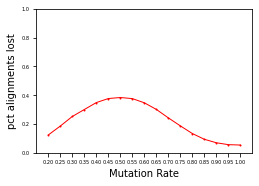

In [83]:
figureHeight = 4
figureWidth = 5

plt.figure(figsize=(figureWidth, figureHeight))

mainPanelWidth = 3 / figureWidth
mainPanelHeight = 2 / figureHeight

mainPanel = plt.axes([0.2, 0.165, mainPanelWidth, mainPanelHeight])
mainPanel.set_xlim(-1, 17)
mainPanel.set_ylim(0, 1)
mainPanel.tick_params(bottom=True, labelbottom=True,
                   left=True, labelleft=True,
                   right=False, labelright=False,
                   top=False, labeltop=False,labelsize=5)
mainPanel.set_xlabel('Mutation Rate')
mainPanel.set_ylabel('pct alignments lost')

mainPanel.plot(new_df['mutation_rate'], new_df['pct alignments lost'],
            marker='o',
            markerfacecolor=('red'),
            markeredgecolor='black',
            markersize=2.0,
            markeredgewidth=0,
            linewidth=1,
            color='red')
plt.savefig('/home/liam/testing/mappability.png', dpi=600)